# **Mental Health Sentiment Analysis**

# **Install and Importing Libraries**

In [ ]:
!pip install nltk seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GRU, Dense

# **Download NLTK**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# **Load Dataset**

In [ ]:
df = pd.read_csv('Mental Health Dataset.csv')

df.head()

,posts,predicted,intensity
0,I know as parent of child with down syndrome t...,negative,-1
1,but in my heart I know this is the future prom...,neutral,0
2,I have mylefibrosis which turn to leukemia the...,negative,-1
3,from one of my health group subject wayne dyer...,neutral,0
4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0


# **Dataset Info**

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()

Dataset Shape: (10392, 3)

Columns: Index(['posts', 'predicted', 'intensity'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10392 entries, 0 to 10391
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   posts      10391 non-null  object
 1   predicted  10392 non-null  object
 2   intensity  10392 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 243.7+ KB


# **Label Distribution**

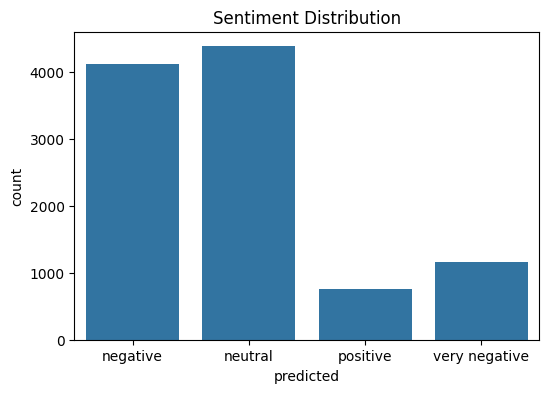

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='predicted', data=df)
plt.title("Sentiment Distribution")
plt.show()

# **Text Length Analysis**

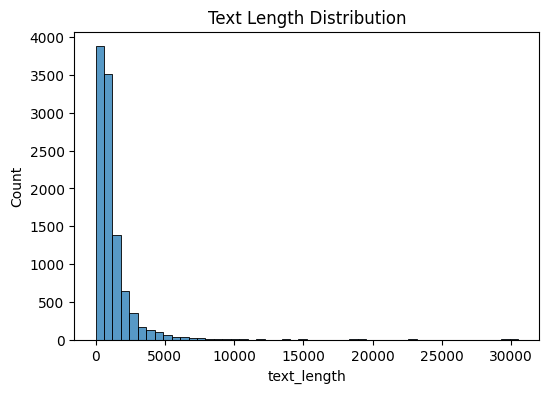

In [ ]:
df['text_length'] = df['posts'].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

# **Preprocessing**

In [ ]:
print(df.columns)

Index(['posts', 'predicted', 'intensity', 'text_length'], dtype='object')


In [ ]:
import re
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pickle

# 🔥 Preprocessing function
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        # remove links
    text = re.sub(r'[^a-z\s]', '', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text


# 🔥 Apply preprocessing
df['cleaned_text'] = df['posts'].apply(preprocess_text)

# **Tokenization and Encoding**

In [ ]:

# 🔥 Tokenization
VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)


# 🔥 Label Encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['predicted'])


# 🔥 Save tokenizer & label encoder (IMPORTANT for deployment)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


# 🔥 Check outputs
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Classes:", label_encoder.classes_)

Shape of X: (10392, 100)
Shape of y: (10392,)
Classes: ['negative' 'neutral' 'positive' 'very negative']


# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **LSTM Model**

# **Import Callback**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# **Define LSTM Modal**

In [ ]:
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(len(label_encoder.classes_), activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Early Stopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# **Train LSTM**

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.5763 - loss: 0.9915 - val_accuracy: 0.6430 - val_loss: 0.8480
Epoch 2/15
 64/117 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.6988 - loss: 0.7645

KeyboardInterrupt: 

# **Evaluate Model**

In [ ]:
loss, accuracy = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Accuracy: {accuracy:.4f}")

# **Predictions and Report**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = lstm_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

labels = np.unique(y_test)

print(classification_report(
    y_test,
    y_pred_classes,
    labels=labels,
    target_names=label_encoder.classes_[labels]
))

# **Accuracy Graph**

In [ ]:
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# **Loss Graph**

In [ ]:
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **BiDirectional LSTM Model**

# **Import Libraries**

In [ ]:
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# **Define BiLSTM Model**

In [ ]:
bilstm_model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(len(label_encoder.classes_), activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

# **Early Stopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# **Train BiLSTM**

In [ ]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# **Evaluate**

In [ ]:
loss, accuracy = bilstm_model.evaluate(X_test, y_test)
print(f"BiLSTM Accuracy: {accuracy:.4f}")

# **Predictions and Report**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = bilstm_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

labels = np.unique(y_test)

print(classification_report(
    y_test,
    y_pred_classes,
    labels=labels,
    target_names=label_encoder.classes_[labels]
))

# **Accuracy**

In [ ]:
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title("BiLSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# **Loss**

In [ ]:
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title("BiLSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **GRU Model**

# **Dataset Balance**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

# **Import Libraries**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# **Set Parameters**

In [ ]:
VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 400   # better for long text
EMBED_DIM = 128

# **Define GRU Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

num_classes = len(label_encoder.classes_)

gru_model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_SEQUENCE_LENGTH),

    GRU(64, return_sequences=True),
    GRU(32),

    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# **Compile**

In [ ]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

# **Train GRU**

In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# **Evaluate Model**

In [ ]:
loss, accuracy = gru_model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# **BiDirectional Lstm with multiple layers**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.626167520337451), 1: np.float64(0.5989193083573487), 2: np.float64(3.3412379421221865), 3: np.float64(2.304046563192905)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

vocab_size = 15000
num_classes = len(np.unique(y_train))

model = Sequential([
    Embedding(vocab_size, 128, input_length=100),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 97s 353ms/step - accuracy: 0.4867 - loss: 1.1933 - val_accuracy: 0.4295 - val_loss: 1.2884
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 343ms/step - accuracy: 0.4914 - loss: 1.1276 - val_accuracy: 0.5233 - val_loss: 1.0476
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 343ms/step - accuracy: 0.5880 - loss: 0.9593 - val_accuracy: 0.6325 - val_loss: 0.8724
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 90s 344ms/step - accuracy: 0.6805 - loss: 0.7704 - val_accuracy: 0.5633 - val_loss: 1.0040
Epoch 5/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 142s 343ms/step - accuracy: 0.7327 - loss: 0.6263 - val_accuracy: 0.6330 - val_loss: 0.9216
Epoch 6/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 341ms/step - accuracy: 0.7830 - loss: 0.5272 - val_accuracy: 0.6397 - val_loss: 0.9583


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.6325 - loss: 0.8724
Accuracy: 0.6325156092643738


# **Predictions and Report**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = gru_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

labels = np.unique(y_test)

print(classification_report(
    y_test,
    y_pred_classes,
    labels=labels,
    target_names=label_encoder.classes_[labels]
))

In [ ]:
models = {
    "LSTM": lstm_model,
    "BiLSTM": bilstm_model,
    "GRU": gru_model
}

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} Accuracy: {acc:.4f}")

# **Prediction Function**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_text(text):
    # 🔥 preprocess (same as training)
    cleaned = preprocess_text(text)

    # 🔥 convert to sequence
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)

    # 🔥 model prediction
    pred = model.predict(padded, verbose=0)[0]

    confidence = np.max(pred)
    label = label_encoder.classes_[np.argmax(pred)]

    return label, confidence

# **Validations**

In [ ]:
text = """hi I write a post sometime ago about my sister in law that terminal with cancer and a lot of you were very supportive and I thank you very much for that her last doctor visit show the cancer have now move into her lip and her brain is swell the doctor take away her drive previage and now she feel the loss of her independence she have been in the hospital several time where they do not think she would come out fact one time they decide to take she off life support and she make it back once again she a good woman and I do not know why she is suffer this way I know life is not fair death is not either but I just do not understand all this suffering and feeling of loss and suffering before her time come do anyone have any word of advice meria"""

print("Prediction:", predict_text(text))

Prediction: ('very negative', np.float32(0.536397))


In [ ]:
text = """hi I am a 30 year old and lose my husband to leukemia on the 20th november 2011 we have four very beautiful child the old being 11 the twin 3 young 4 month I am so sad today I so very much miss he and it hurt so much I want he here and wish I could do anything to bring he back he was 32 and a young man and the awesome man father he was should of never leave I know that it was not his fault or mine it do not change how much I miss he or how much it hurt that he is not here I hate this so much go through the day to day with out he make decision myself without ask he I never make decision myself he always help jason is my husband name and an awesome man he was and will always will be no one will ever be as good as a man that he is or was but man I miss he so very much how do you get through this when you lose someone so special someone you care about so deeply someone who father you child and it hurt so very much we find out on october 15 and he pass on the 19th the day before the twin birthday the twin were his first bio child even though our first was not his bio child he still treat she like his own all of our child were miracale child the twin were invetro and our four month old is our angle he come without anything so unexpected and so worth everything just not sure why he have to get sick and why he have to leave at such a very young age nothing of how or even what I am feel I can not express how this feel to lose someone precious"""

print("Prediction:", predict_text(text))

Prediction: ('very negative', np.float32(0.6473298))


In [ ]:
text = """hello all I am new here so I am sorry if I am post in the wrong spot my mom was diagnose with non small cell lung cancer with met to the brain she have the cyberknife treatment on the brain met now they have she on chemo and also tarceva to shrink the lung tumor I am wonder why can not they just do cyberknife on the lung tumor now is there a health risk to do radiosurgery without shrink the tumor she have only have one round of chemo and is sick like you would not believe please I would appreciate any input anyone can give I	"""

print("Prediction:", predict_text(text))

Prediction: ('negative', np.float32(0.8045492))


In [ ]:
text = """hi guy I am the first in my family with apkd and win the jackpot because my liver is enormous as well before pregnancy I have a normal figure but after give birth my liver start to explode now it is 6 time as big as it should be and really impare quality of life my son is eleven year old now and we just find out that he have hypertension I have decide that I will opt for a combine liver and kidney transplant in belgium I live in the netherlands is there anyone here who have survive this regard nicky"""

print("Prediction:", predict_text(text))

Prediction: ('neutral', np.float32(0.38421923))


In [ ]:
text = """timeline january dark mole that start grow while I was pregnant in 2010 come back abnormal february tongue start feel weird and burning go to doctor and he do blood work go to get the blood work and it was the day after the peak of a bad cold wbc count come back pretty low 2 9 doctor say it was probably because of cold march go to ent for check up he see low wbc count in system and send I to have it re check and to set up a follow up in a week the entire week I was google and convince I have leukemia complete shutdown mode go for the follow up and all my level were back to normal april start back on zoloft I have been off of it since get pregnant in january 2010 and breastfeed until october 2011 may have diarrhea for a couple day and then stool turn yellow and start to have leave upper side pain convince it was either stomach colon or pancreatic cancer I was quite the social drinker through my 20 and still drink on the weekend with husband and friend when I was not pregnant or breastfeed june go to the doctor for the side pain and was refer to gi july go to gi and he decide since I do have gerd the side pain and stomach burn he want to do an endoscopy august have endoscopy do esophagus stomach and upper duodenum were find to be normal my stomach was a bit red and irritated so they test for h pylori and it come back negative have to do follow up with gi soon thursday of last week a painless white patch bump show up in my mouth and I freak out think it was oral cancer which is what I think the tongue burning was too I could not get an appointment so I have the weekend to worry the patch bump go away and all that is leave is a little white but I still can not get rid of this anxiety think it is go to come back I am also very freak out because I am so tired but I have been go to bed early and sleep in but I still feel so tired I can not seem to shake this as you can see it is one thing after another my hypochondria was dormant for so long before january and now it is here and do not want to leave I am on 100 mg of zoloft and it do not seem to be work all that well I still have overwhelming anxiety and constant thought something is wrong and the checking check my neck the back of my mouth press on my left side when I feel a pain to see if it would be in the path of the tail end of my pancrea I am so sick of this what should I do	"""

print("Prediction:", predict_text(text))

Prediction: ('negative', np.float32(0.7084584))


In [ ]:
print(predict_text("I feel very happy today"))
print(predict_text("I am feeling sad and tired"))
print(predict_text("I want to end everything"))

('neutral', np.float32(0.6044929))
('very negative', np.float32(0.7506693))
('neutral', np.float32(0.6442872))


In [ ]:
model.save("final_model.h5")

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [ ]:
from google.colab import files

files.download("final_model.h5")
files.download("tokenizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>